3.5810146364971696e-17
1.0
34.64823227814062
34.64823227814062
特征向量的验证结果：通过
原始特征值： [np.complex128(24.5+24.5j), np.complex128(24+24j), np.complex128(23.5+23.5j), np.complex128(23+23j), np.complex128(22.5+22.5j), np.complex128(22+22j), np.complex128(21.5+21.5j), np.complex128(21+21j), np.complex128(20.5+20.5j), np.complex128(20+20j), np.complex128(19.5+19.5j), np.complex128(19+19j), np.complex128(18.5+18.5j), np.complex128(18+18j), np.complex128(17.5+17.5j), np.complex128(17+17j), np.complex128(16.5+16.5j), np.complex128(16+16j), np.complex128(15.5+15.5j), np.complex128(15+15j), np.complex128(14.5+14.5j), np.complex128(14+14j), np.complex128(13.5+13.5j), np.complex128(13+13j), np.complex128(12.5+12.5j), np.complex128(12+12j), np.complex128(11.5+11.5j), np.complex128(11+11j), np.complex128(10.5+10.5j), np.complex128(10+10j), np.complex128(9.5+9.5j), np.complex128(9+9j), np.complex128(8.5+8.5j), np.complex128(8+8j), np.complex128(7.5+7.5j), np.complex128(7+7j), np.complex128(6.5+6.5j), np.

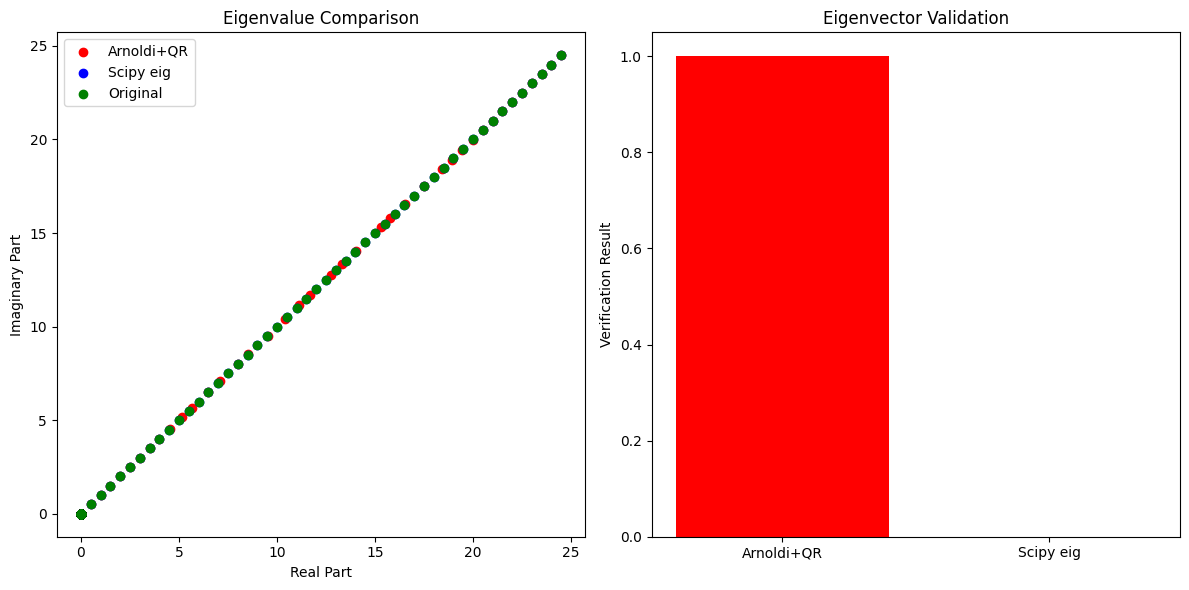

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.linalg import orth

# 生成复数稀疏矩阵 A，基于给定的复特征值和复特征向量


def generate_sparse_matrix_complex(eigenvalues, eigenvectors):
    D = np.diag(eigenvalues)  # 特征值的对角矩阵
    A = eigenvectors @ D @ np.linalg.inv(eigenvectors)  # 矩阵 A = P * D * P^(-1)
    return A

# Arnoldi 算法（Krylov 子空间生成器）


def arnoldi_iteration_complex(A, k):  # cpu or gpu
    n = A.shape[0]  # 获取矩阵 A 的大小
    Q = np.zeros((n, k + 1), dtype=np.complex128)  # 用于存储基向量的矩阵
    H = np.zeros((k + 1, k), dtype=np.complex128)  # 用于存储上 Hessenberg 矩阵 H
    q = np.random.rand(n) + 1j * np.random.rand(n)  # 随机生成复数初始向量 q
    q = q / np.linalg.norm(q)  # 将向量 q 归一化，使其模长为 1
    Q[:, 0] = q  # 将归一化后的 q 作为第一个基向量

    for j in range(k):
        v = A @ Q[:, j]  # v = A * qj
        for i in range(j + 1):
            H[i, j] = np.dot(Q[:, i].conj(), v)  # 计算 H[i, j] = q_i^T * v
            v -= H[i, j] * Q[:, i]  # Gram-Schmidt 正交化过程
        H[j + 1, j] = np.linalg.norm(v)  # H[j + 1, j] = ||v||
        if H[j + 1, j] != 0 and j + 1 < n:
            Q[:, j + 1] = v / H[j + 1, j]  # q_(j+1) = v / ||v||
    return Q[:, :-1], H[:-1, :]  # 返回正交基向量矩阵 Q 和上 Hessenberg 矩阵 H

# QR 算法求解特征值和特征向量


def qr_algorithm_complex(H, max_iter=5000, tol=1e-9):  # cpu or gpu
    n = H.shape[0]  # 获取矩阵 H 的维度（假设为 n x n）
    for i in range(max_iter):
        Q = np.zeros((n, n), dtype=np.complex128)  # 正交矩阵 Q
        R = np.zeros((n, n), dtype=np.complex128)  # 上三角矩阵 R
        for j in range(n):
            v = H[:, j]  # 当前列
            for k in range(j):
                R[k, j] = np.dot(Q[:, k].conj(), v)  # 计算 R[k, j]
                v -= R[k, j] * Q[:, k]  # 从 v 中减去与 Q[:, k] 的投影
            norm_v = np.linalg.norm(v)  # 计算 v 的范数
            if norm_v > tol:
                R[j, j] = norm_v
                Q[:, j] = v / R[j, j]  # 归一化 v
            else:
                R[j, j] = 1e-10  # 如果范数小于阈值，设置 R[j, j] 为一个小的数值
                Q[:, j] = v
        H = np.dot(R, Q)  # 计算新的 H = R * Q
        if np.all(np.abs(H - np.diag(np.diag(H))) < tol):  # 判断是否收敛
            break
    eigenvector_error = validate_eigenvector_complex(
        H, np.diag(H)[0], Q[:, 0])
    print(f"特征向量的验证结果：{'通过' if eigenvector_error else '未通过'}")
    return np.diag(H), Q  # 返回对角线上的特征值和特征向量 Q

# 优化特征向量验证函数（验证 A * v = lambda * v）


def validate_eigenvector_complex(A, eigenvalue, eigenvector, tol=1e-9):
    Av = A @ eigenvector
    lambda_v = eigenvalue * eigenvector
    error = np.linalg.norm(Av - lambda_v) / np.linalg.norm(Av)
    print(error)
    print(np.linalg.norm(eigenvector))
    print(np.linalg.norm(Av))
    print(np.linalg.norm(lambda_v))
    return error < tol  # 如果误差小于容忍度，认为验证成功


# 主程序
if __name__ == "__main__":
    N = 1000
    n = 50
    # 已知复特征值和复特征向量
    eigenvalues = np.array([i * 0.5 + 1j * (i * 0.5)
                           for i in range(n)] + [0] * (N-n))  # 生成复数特征值
    eigenvectors = orth(np.random.rand(N, N) + 1j *
                        np.random.rand(N, N))  # 随机生成复数正交特征向量矩阵
    A = generate_sparse_matrix_complex(
        eigenvalues, eigenvectors)  # 根据复特征值和特征向量生成复数稀疏矩阵 A

    # 使用 Arnoldi 算法提取 Krylov 子空间
    k = 40  # 增加 Krylov 子空间的维度 # 大于n时效果好，所以如何知道n呢。。。
    Q, H = arnoldi_iteration_complex(A, k)  # 获取基向量矩阵 Q 和上 Hessenberg 矩阵 H

    # 使用 QR 算法计算 H 的特征值和特征向量
    estimated_eigenvalues, estimated_eigenvectors = qr_algorithm_complex(
        H, max_iter=5000)  # 估计的特征值和特征向量

    # 排序特征值和特征向量
    idx = np.argsort(np.abs(estimated_eigenvalues))[::-1]  # 按特征值的绝对值从大到小排序
    estimated_eigenvalues = estimated_eigenvalues[idx]
    estimated_eigenvectors = estimated_eigenvectors[:, idx]

    # 通过 Q 将 H 的特征向量映射到原始矩阵 A 的特征向量空间 # 存在一定问题，下面的示例却能通过？？？
    estimated_eigenvectors = Q @ estimated_eigenvectors

    # 使用 scipy.linalg.eig 计算特征值和特征向量
    scipy_eigenvalues, scipy_eigenvectors = eig(A)

    # 输出计算结果
    print("原始特征值：", sorted(eigenvalues,
          key=lambda x: abs(x), reverse=True))  # 输出原始复特征值
    print("估计特征值：", sorted(estimated_eigenvalues,
          key=lambda x: abs(x), reverse=True))  # 输出估计的特征值
    print("Scipy 计算的特征值：", sorted(scipy_eigenvalues,
          key=lambda x: abs(x), reverse=True))  # 输出Scipy计算的特征值

    # 验证特征向量和特征值的关系
    eigenvector_error = validate_eigenvector_complex(
        A, estimated_eigenvalues[0], estimated_eigenvectors[:, 0])
    print(f"特征向量的验证结果：{'通过' if eigenvector_error else '未通过'}")
    eigenvector_error = validate_eigenvector_complex(
        A, scipy_eigenvalues[0], scipy_eigenvectors[:, 0])
    print(f"特征向量的验证结果：{'通过' if eigenvector_error else '未通过'}")

    # 绘制特征值对比图
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.scatter(np.real(estimated_eigenvalues), np.imag(
        estimated_eigenvalues), color='r', label='Arnoldi+QR')
    plt.scatter(np.real(scipy_eigenvalues), np.imag(
        scipy_eigenvalues), color='b', label='Scipy eig')
    plt.scatter(np.real(eigenvalues), np.imag(
        eigenvalues), color='g', label='Original')
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.title('Eigenvalue Comparison')
    plt.legend()

    # 绘制特征向量的验证结果
    plt.subplot(1, 2, 2)
    plt.bar([0, 1], [eigenvector_error, 1 - eigenvector_error],
            tick_label=['Arnoldi+QR', 'Scipy eig'], color=['r', 'b'])
    plt.ylabel('Verification Result')
    plt.title('Eigenvector Validation')

    plt.tight_layout()
    plt.show()

In [102]:
import numpy as np
from scipy.linalg import eig

# Arnoldi 迭代
def arnoldi_iteration(A, k):
    n = A.shape[0]
    Q = np.zeros((n, k), dtype=np.complex128)  # 用于存储基向量的矩阵
    H = np.zeros((k, k), dtype=np.complex128)  # 用于存储 Hessenberg 矩阵 H
    q = np.random.rand(n) + 1j * np.random.rand(n)  # 随机生成复数初始向量
    q = q / np.linalg.norm(q)  # 将向量 q 归一化
    Q[:, 0] = q  # 将归一化后的 q 作为第一个基向量

    for j in range(k - 1):
        v = A @ Q[:, j]  # v = A * qj
        for i in range(j + 1):
            H[i, j] = np.dot(Q[:, i].conj(), v)  # 计算 H[i, j]
            v -= H[i, j] * Q[:, i]  # Gram-Schmidt 正交化过程
        H[j + 1, j] = np.linalg.norm(v)  # 计算 H[j+1, j] 的值
        if H[j + 1, j] != 0:
            Q[:, j + 1] = v / H[j + 1, j]  # 归一化 v
    return Q, H  # 返回正交基矩阵 Q 和上 Hessenberg 矩阵 H

# 使用 Arnoldi 迭代生成 Krylov 子空间
n = 100  # 矩阵维度
k = 10   # 子空间维度
A = np.random.rand(n, n) + 1j * np.random.rand(n, n)  # 随机生成复矩阵 A

Q, H = arnoldi_iteration(A, k)

# 计算 H 的特征值和特征向量
eigenvalues_H, eigenvectors_H = np.linalg.eig(H)

# 排序特征值和特征向量
idx = np.argsort(np.abs(eigenvalues_H))[::-1]  # 按特征值的绝对值从大到小排序
eigenvalues_H_sorted = eigenvalues_H[idx]
eigenvectors_H_sorted = eigenvectors_H[:, idx]

# eigenvalues_H_sorted = eigenvalues_H
# eigenvectors_H_sorted = eigenvectors_H

# 通过 Q 将 H 的特征向量映射到原始矩阵 A 的特征向量空间
eigenvectors_A = Q @ eigenvectors_H_sorted

# 输出计算的特征值和特征向量
print("H 的特征值：", eigenvalues_H_sorted)
print("映射回 A 的特征向量：", eigenvectors_A)

# 验证特征向量和特征值的关系
def validate_eigenvector_complex(A, eigenvalue, eigenvector, tol=1e-6):
    Av = A @ eigenvector
    lambda_v = eigenvalue * eigenvector
    error = np.linalg.norm(Av - lambda_v)/np.linalg.norm(Av)
    print("误差：", error)
    return error < tol  # 如果误差小于容忍度，认为验证成功

# 验证特征向量的准确性
eigenvector_error = validate_eigenvector_complex(
    A, eigenvalues_H_sorted[0], eigenvectors_A[:, 0])
print(f"特征向量的验证结果：{'通过' if eigenvector_error else '未通过'}")


H 的特征值： [50.48110694+50.20815456j  2.23974614 -3.1703555j
 -0.87596724 +3.54032757j -3.60929036 +0.45376467j
  3.44364898 -0.3048378j  -0.52441794 -2.99279569j
  1.44548217 +2.08789744j -1.26611976 -1.28051866j
 -0.78443463 +0.77947777j  0.         +0.j        ]
映射回 A 的特征向量： [[ 6.02969507e-02+7.10573286e-02j  5.65693272e-02-1.93925109e-02j
   8.48457112e-02-9.77983984e-03j  1.10561083e-01+1.11219139e-02j
   1.27902924e-02-1.23870472e-01j  1.41742147e-02-5.16676677e-02j
   8.03879978e-02-4.04803112e-02j  4.03493111e-02-6.18043008e-03j
   9.81421850e-02-6.82215542e-03j  8.80199723e-02-2.81797721e-02j]
 [ 6.24720314e-02+7.52860245e-02j -6.63868619e-02+1.31647743e-02j
   9.38715253e-02+3.46727480e-02j -5.80847489e-02-7.81929504e-03j
  -4.78142401e-06-1.75987748e-02j -2.43085519e-02+8.16195330e-02j
   3.44370199e-03+9.62699029e-02j -5.52340630e-02+7.69890880e-02j
  -1.80292008e-02+8.60474600e-02j -2.90484497e-02+7.36715517e-02j]
 [ 6.54104930e-02+7.40673790e-02j -4.93829664e-02-4.85173879e-